In [ ]:

# Install required packages
import subprocess
import sys

# Install scikit-image and PyWavelets
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-image", "PyWavelets"])

print("Required packages installed successfully")


NEWRELIC: 2025-12-03 14:00:11 (57) - New Relic could not start because the newrelic-admin script was called from a Python installation that is different from the Python installation that is currently running. To fix this problem, call the newrelic-admin script from the Python installation that is currently running (details below).

newrelic-admin Python directory: None
current Python directory: '/app/miniconda'
newrelic-admin Python version: None
current Python version: '3.12'


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
clipkit 2.6.1 requires numpy<2.1,>=1.26.0; python_version == "3.12", but you have numpy 2.3.5 which is incompatible.
coredis 5.3.0 requires typing-extensions>=4.13, but you have typing-extensions 4.12.2 which is incompatible.
fcsparser 0.2.8 requires numpy<2,>=1, but you have numpy 2.3.5 which is incompatible.
fhda 1.0.0 requires python-json-logger>=4.0.0, but you have python-json-logger 2.0.7 which is incompatible.
numpydoc 1.5.0 requires sphinx>=4.2, but you have sphinx 3.5.3 which is incompatible.


Required packages installed successfully


In [ ]:

# Step 1: Define Analysis Plan and Setup
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import scipy.ndimage as ndimage
from scipy.ndimage import sobel
from skimage.restoration import denoise_tv_chambolle
from skimage.filters.rank import entropy
from skimage.morphology import disk
import pywt
from scipy.stats import entropy as scipy_entropy
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print("\n=== Analysis Plan ===")
print("1. Select representative images (one benign, one malignant)")
print("2. Simulate compressed sensing with 30% sampling rate and 25 dB SNR")
print("3. Reconstruct using TV-only method (50 iterations, step size 0.001)")
print("4. Reconstruct using Adaptive-HASA method (50 iterations, adaptive weights)")
print("5. Generate difference maps and visualizations with tumor boundaries")
print("6. Analyze error patterns at tumor boundaries")


Libraries imported successfully

=== Analysis Plan ===
1. Select representative images (one benign, one malignant)
2. Simulate compressed sensing with 30% sampling rate and 25 dB SNR
3. Reconstruct using TV-only method (50 iterations, step size 0.001)
4. Reconstruct using Adaptive-HASA method (50 iterations, adaptive weights)
5. Generate difference maps and visualizations with tumor boundaries
6. Analyze error patterns at tumor boundaries


In [ ]:

# Step 2: Explore dataset and select representative images
# We'll select images with clear tumor boundaries for visualization

base_dir = Path("Dataset_BUSI_with_GT")

# List benign images
benign_dir = base_dir / "benign"
benign_images = sorted([f for f in os.listdir(benign_dir) if f.endswith('.png') and '_mask' not in f])

# List malignant images
malignant_dir = base_dir / "malignant"
malignant_images = sorted([f for f in os.listdir(malignant_dir) if f.endswith('.png') and '_mask' not in f])

print(f"Total benign images: {len(benign_images)}")
print(f"Total malignant images: {len(malignant_images)}")

# Select representative images - let's choose from middle of dataset
# and verify they have masks
benign_img_name = "benign (50).png"
malignant_img_name = "malignant (50).png"

# Check if these exist and have masks
benign_img_path = benign_dir / benign_img_name
benign_mask_path = benign_dir / benign_img_name.replace('.png', '_mask.png')

malignant_img_path = malignant_dir / malignant_img_name
malignant_mask_path = malignant_dir / malignant_img_name.replace('.png', '_mask.png')

print(f"\nSelected benign image: {benign_img_name}")
print(f"  Image exists: {benign_img_path.exists()}")
print(f"  Mask exists: {benign_mask_path.exists()}")

print(f"\nSelected malignant image: {malignant_img_name}")
print(f"  Image exists: {malignant_img_path.exists()}")
print(f"  Mask exists: {malignant_mask_path.exists()}")


Total benign images: 437
Total malignant images: 210

Selected benign image: benign (50).png
  Image exists: True
  Mask exists: True

Selected malignant image: malignant (50).png
  Image exists: True
  Mask exists: True


In [ ]:

# Step 3: Load and preprocess selected images
# Convert to grayscale, resize to 128x128, normalize to [0,1]

def load_and_preprocess_image(img_path, target_size=(128, 128)):
    """Load image, convert to grayscale, resize, and normalize to [0,1]"""
    img = Image.open(img_path)
    # Convert to grayscale
    img_gray = img.convert('L')
    # Resize to target size
    img_resized = img_gray.resize(target_size, Image.BILINEAR)
    # Convert to numpy array and normalize to [0,1]
    img_array = np.array(img_resized, dtype=np.float64) / 255.0
    return img_array

def load_and_preprocess_mask(mask_path, target_size=(128, 128)):
    """Load mask, resize, and binarize"""
    mask = Image.open(mask_path)
    # Convert to grayscale if needed
    mask_gray = mask.convert('L')
    # Resize to target size
    mask_resized = mask_gray.resize(target_size, Image.NEAREST)
    # Convert to binary (threshold at 128)
    mask_array = np.array(mask_resized, dtype=np.float64)
    mask_binary = (mask_array > 128).astype(np.float64)
    return mask_binary

# Load benign case
benign_gt = load_and_preprocess_image(benign_img_path)
benign_mask = load_and_preprocess_mask(benign_mask_path)

# Load malignant case
malignant_gt = load_and_preprocess_image(malignant_img_path)
malignant_mask = load_and_preprocess_mask(malignant_mask_path)

print("Benign image:")
print(f"  Shape: {benign_gt.shape}")
print(f"  Range: [{benign_gt.min():.3f}, {benign_gt.max():.3f}]")
print(f"  Mask coverage: {benign_mask.sum() / benign_mask.size * 100:.1f}%")

print("\nMalignant image:")
print(f"  Shape: {malignant_gt.shape}")
print(f"  Range: [{malignant_gt.min():.3f}, {malignant_gt.max():.3f}]")
print(f"  Mask coverage: {malignant_mask.sum() / malignant_mask.size * 100:.1f}%")


Benign image:
  Shape: (128, 128)
  Range: [0.004, 0.969]
  Mask coverage: 2.8%

Malignant image:
  Shape: (128, 128)
  Range: [0.004, 0.984]
  Mask coverage: 8.0%


In [ ]:

# Step 4: Implement compressed sensing simulation
# Generate Gaussian measurement matrix with 30% sampling rate and add 25 dB noise

def generate_cs_measurements(image, sampling_rate=0.3, snr_db=25, seed=42):
    """
    Generate compressed sensing measurements with Gaussian measurement matrix
    
    Parameters:
    - image: 2D numpy array (ground truth image)
    - sampling_rate: fraction of measurements to take (e.g., 0.3 for 30%)
    - snr_db: signal-to-noise ratio in decibels
    - seed: random seed for reproducibility
    
    Returns:
    - Phi: measurement matrix (m x n)
    - y: measurement vector (m,)
    """
    np.random.seed(seed)
    
    # Flatten image
    x = image.flatten()
    n = len(x)
    
    # Number of measurements
    m = int(n * sampling_rate)
    
    # Generate Gaussian measurement matrix (normalized)
    Phi = np.random.randn(m, n) / np.sqrt(m)
    
    # Generate measurements
    y_clean = Phi @ x
    
    # Calculate signal power
    signal_power = np.mean(y_clean ** 2)
    
    # Calculate noise power from desired SNR
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    
    # Generate and add noise
    noise = np.sqrt(noise_power) * np.random.randn(m)
    y = y_clean + noise
    
    return Phi, y, m, n

# Generate CS measurements for both images
benign_Phi, benign_y, benign_m, benign_n = generate_cs_measurements(benign_gt)
malignant_Phi, malignant_y, malignant_m, malignant_n = generate_cs_measurements(malignant_gt)

print("Compressed sensing setup:")
print(f"  Image size: {benign_gt.shape[0]} x {benign_gt.shape[1]} = {benign_n} pixels")
print(f"  Sampling rate: 30%")
print(f"  Number of measurements: {benign_m}")
print(f"  Measurement matrix shape: {benign_Phi.shape}")
print(f"  Compression ratio: {benign_n / benign_m:.2f}:1")
print(f"  Target SNR: 25 dB")


Compressed sensing setup:
  Image size: 128 x 128 = 16384 pixels
  Sampling rate: 30%
  Number of measurements: 4915
  Measurement matrix shape: (4915, 16384)
  Compression ratio: 3.33:1
  Target SNR: 25 dB


In [ ]:

# Step 5: Implement TV-only reconstruction using proximal gradient descent

def tv_reconstruction(Phi, y, img_shape, max_iter=50, step_size=0.001, tv_weight=0.1):
    """
    TV-only reconstruction using proximal gradient descent
    
    Parameters:
    - Phi: measurement matrix (m x n)
    - y: measurement vector (m,)
    - img_shape: tuple (height, width) for reshaping
    - max_iter: number of iterations
    - step_size: gradient descent step size
    - tv_weight: weight for TV denoising
    
    Returns:
    - x_recon: reconstructed image
    """
    n = img_shape[0] * img_shape[1]
    
    # Initialize with backprojection
    x = Phi.T @ y
    
    # Proximal gradient descent
    for i in range(max_iter):
        # Data fidelity gradient: Phi^T (Phi x - y)
        residual = Phi @ x - y
        gradient = Phi.T @ residual
        
        # Gradient descent step
        x = x - step_size * gradient
        
        # TV proximal operator (denoise_tv_chambolle)
        x_img = x.reshape(img_shape)
        x_img = denoise_tv_chambolle(x_img, weight=tv_weight)
        x = x_img.flatten()
        
        if (i + 1) % 10 == 0:
            mse = np.mean(residual ** 2)
            print(f"  Iteration {i+1}/{max_iter}, MSE: {mse:.6f}")
    
    return x.reshape(img_shape)

print("Reconstructing benign image with TV-only method...")
start_time = time.time()
benign_tv_recon = tv_reconstruction(benign_Phi, benign_y, benign_gt.shape)
benign_tv_time = time.time() - start_time
print(f"  Reconstruction time: {benign_tv_time:.2f} seconds")

print("\nReconstructing malignant image with TV-only method...")
start_time = time.time()
malignant_tv_recon = tv_reconstruction(malignant_Phi, malignant_y, malignant_gt.shape)
malignant_tv_time = time.time() - start_time
print(f"  Reconstruction time: {malignant_tv_time:.2f} seconds")


Reconstructing benign image with TV-only method...


  Iteration 10/50, MSE: 0.035663


  Iteration 20/50, MSE: 0.048964


  Iteration 30/50, MSE: 0.060452


  Iteration 40/50, MSE: 0.068428


...

  Iteration 10/50, MSE: 0.013623


  Iteration 20/50, MSE: 0.019405


  Iteration 30/50, MSE: 0.022761


  Iteration 40/50, MSE: 0.025102


  Iteration 50/50, MSE: 0.027003
  Reconstruction time: 2.04 seconds


In [ ]:

# Step 6: Implement Adaptive-HASA reconstruction
# Combines TV and wavelet regularization with adaptive weights based on local image statistics

def compute_adaptive_weights(image, window_size=7):
    """
    Compute adaptive weights based on local gradient magnitude and entropy
    Higher weights for TV in smooth regions, higher weights for wavelet in textured regions
    """
    # Compute local gradient magnitude
    grad_x = sobel(image, axis=0)
    grad_y = sobel(image, axis=1)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    
    # Normalize gradient magnitude to [0, 1]
    grad_mag_norm = (grad_mag - grad_mag.min()) / (grad_mag.max() - grad_mag.min() + 1e-8)
    
    # Compute local entropy using a sliding window
    # Convert image to uint8 for entropy calculation
    img_uint8 = (image * 255).astype(np.uint8)
    local_entropy = entropy(img_uint8, disk(window_size // 2))
    local_entropy_norm = (local_entropy - local_entropy.min()) / (local_entropy.max() - local_entropy.min() + 1e-8)
    
    # TV weight: higher in smooth regions (low gradient, low entropy)
    tv_weight = 1.0 - 0.5 * (grad_mag_norm + local_entropy_norm)
    
    # Wavelet weight: higher in textured regions (high gradient, high entropy)
    wavelet_weight = 0.5 * (grad_mag_norm + local_entropy_norm)
    
    return tv_weight, wavelet_weight

def wavelet_soft_threshold(image, threshold, wavelet='db4', level=3):
    """
    Apply wavelet soft thresholding
    """
    # Perform wavelet decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Threshold detail coefficients
    coeffs_thresh = [coeffs[0]]  # Keep approximation coefficients
    for detail_level in coeffs[1:]:
        coeffs_thresh.append(tuple([pywt.threshold(c, threshold, mode='soft') for c in detail_level]))
    
    # Reconstruct
    img_recon = pywt.waverec2(coeffs_thresh, wavelet)
    
    # Handle size mismatch due to wavelet transform
    if img_recon.shape != image.shape:
        img_recon = img_recon[:image.shape[0], :image.shape[1]]
    
    return img_recon

def adaptive_hasa_reconstruction(Phi, y, img_shape, max_iter=50, step_size=0.001, 
                                  tv_weight_base=0.1, wavelet_threshold=0.05, 
                                  update_weights_every=5):
    """
    Adaptive-HASA reconstruction combining TV and wavelet regularization
    with adaptive weights based on local image statistics
    """
    n = img_shape[0] * img_shape[1]
    
    # Initialize with backprojection
    x = Phi.T @ y
    
    # Initialize adaptive weights
    x_img = x.reshape(img_shape)
    tv_weights, wavelet_weights = compute_adaptive_weights(x_img)
    
    # Proximal gradient descent
    for i in range(max_iter):
        # Data fidelity gradient: Phi^T (Phi x - y)
        residual = Phi @ x - y
        gradient = Phi.T @ residual
        
        # Gradient descent step
        x = x - step_size * gradient
        
        # Reshape for regularization
        x_img = x.reshape(img_shape)
        
        # Apply TV denoising with adaptive weights
        tv_denoised = denoise_tv_chambolle(x_img, weight=tv_weight_base)
        
        # Apply wavelet soft thresholding
        wavelet_denoised = wavelet_soft_threshold(x_img, threshold=wavelet_threshold)
        
        # Combine using adaptive weights
        x_img = tv_weights * tv_denoised + wavelet_weights * wavelet_denoised
        
        # Flatten for next iteration
        x = x_img.flatten()
        
        # Update adaptive weights periodically
        if (i + 1) % update_weights_every == 0:
            tv_weights, wavelet_weights = compute_adaptive_weights(x_img)
            mse = np.mean(residual ** 2)
            print(f"  Iteration {i+1}/{max_iter}, MSE: {mse:.6f}, weights updated")
        elif (i + 1) % 10 == 0:
            mse = np.mean(residual ** 2)
            print(f"  Iteration {i+1}/{max_iter}, MSE: {mse:.6f}")
    
    return x.reshape(img_shape)

print("Reconstructing benign image with Adaptive-HASA method...")
start_time = time.time()
benign_hasa_recon = adaptive_hasa_reconstruction(benign_Phi, benign_y, benign_gt.shape)
benign_hasa_time = time.time() - start_time
print(f"  Reconstruction time: {benign_hasa_time:.2f} seconds")

print("\nReconstructing malignant image with Adaptive-HASA method...")
start_time = time.time()
malignant_hasa_recon = adaptive_hasa_reconstruction(malignant_Phi, malignant_y, malignant_gt.shape)
malignant_hasa_time = time.time() - start_time
print(f"  Reconstruction time: {malignant_hasa_time:.2f} seconds")


Reconstructing benign image with Adaptive-HASA method...
  Iteration 5/50, MSE: 2.402627, weights updated


  Iteration 10/50, MSE: 0.140374, weights updated
  Iteration 15/50, MSE: 0.037139, weights updated


  Iteration 20/50, MSE: 0.039595, weights updated
  Iteration 25/50, MSE: 0.043816, weights updated


  Iteration 30/50, MSE: 0.047956, weights updated
  Iteration 35/50, MSE: 0.051391, weights updated


  Iteration 40/50, MSE: 0.054340, weights updated
  Iteration 45/50, MSE: 0.057002, weights updated


...

  Iteration 10/50, MSE: 0.018357, weights updated
  Iteration 15/50, MSE: 0.013840, weights updated


  Iteration 20/50, MSE: 0.015131, weights updated
  Iteration 25/50, MSE: 0.016699, weights updated


  Iteration 30/50, MSE: 0.017911, weights updated


  Iteration 35/50, MSE: 0.018919, weights updated
  Iteration 40/50, MSE: 0.019789, weights updated


  Iteration 45/50, MSE: 0.020533, weights updated
  Iteration 50/50, MSE: 0.021191, weights updated
  Reconstruction time: 1.91 seconds


In [ ]:

# Step 7: Generate difference maps (absolute pixel-wise error)

# Benign case
benign_tv_error = np.abs(benign_tv_recon - benign_gt)
benign_hasa_error = np.abs(benign_hasa_recon - benign_gt)

# Malignant case
malignant_tv_error = np.abs(malignant_tv_recon - malignant_gt)
malignant_hasa_error = np.abs(malignant_hasa_recon - malignant_gt)

print("Difference maps generated")
print("\nBenign case:")
print(f"  TV-only error - Mean: {benign_tv_error.mean():.6f}, Max: {benign_tv_error.max():.6f}")
print(f"  Adaptive-HASA error - Mean: {benign_hasa_error.mean():.6f}, Max: {benign_hasa_error.max():.6f}")

print("\nMalignant case:")
print(f"  TV-only error - Mean: {malignant_tv_error.mean():.6f}, Max: {malignant_tv_error.max():.6f}")
print(f"  Adaptive-HASA error - Mean: {malignant_hasa_error.mean():.6f}, Max: {malignant_hasa_error.max():.6f}")

# Compute PSNR for each reconstruction
def compute_psnr(gt, recon):
    mse = np.mean((gt - recon) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

print("\nPSNR (Peak Signal-to-Noise Ratio):")
print(f"  Benign - TV-only: {compute_psnr(benign_gt, benign_tv_recon):.2f} dB")
print(f"  Benign - Adaptive-HASA: {compute_psnr(benign_gt, benign_hasa_recon):.2f} dB")
print(f"  Malignant - TV-only: {compute_psnr(malignant_gt, malignant_tv_recon):.2f} dB")
print(f"  Malignant - Adaptive-HASA: {compute_psnr(malignant_gt, malignant_hasa_recon):.2f} dB")


Difference maps generated

Benign case:
  TV-only error - Mean: 0.114894, Max: 0.607631
  Adaptive-HASA error - Mean: 0.102027, Max: 0.563970

Malignant case:
  TV-only error - Mean: 0.060831, Max: 0.460619
  Adaptive-HASA error - Mean: 0.052418, Max: 0.426272

PSNR (Peak Signal-to-Noise Ratio):
  Benign - TV-only: 16.63 dB
  Benign - Adaptive-HASA: 17.50 dB
  Malignant - TV-only: 21.10 dB
  Malignant - Adaptive-HASA: 22.18 dB


In [ ]:

# Step 8: Extract tumor boundaries from masks for overlay visualization

def extract_boundary(mask, dilation_size=2):
    """
    Extract boundary of mask by computing the difference between dilated and eroded mask
    """
    from scipy.ndimage import binary_dilation, binary_erosion
    
    # Dilate and erode
    dilated = binary_dilation(mask, iterations=dilation_size)
    eroded = binary_erosion(mask, iterations=dilation_size)
    
    # Boundary is the difference
    boundary = dilated.astype(int) - eroded.astype(int)
    
    return boundary > 0

# Extract boundaries
benign_boundary = extract_boundary(benign_mask)
malignant_boundary = extract_boundary(malignant_mask)

print("Tumor boundaries extracted")
print(f"  Benign boundary pixels: {benign_boundary.sum()}")
print(f"  Malignant boundary pixels: {malignant_boundary.sum()}")


Tumor boundaries extracted
  Benign boundary pixels: 284
  Malignant boundary pixels: 702


In [ ]:

# Step 9: Analyze error patterns at tumor boundaries
# Compute statistics specifically at boundary regions

def compute_boundary_error_stats(error_map, boundary_mask):
    """
    Compute error statistics at boundary regions
    """
    # Extract error values at boundary
    boundary_errors = error_map[boundary_mask]
    
    # Extract error values in non-boundary regions
    non_boundary_errors = error_map[~boundary_mask]
    
    return {
        'boundary_mean': np.mean(boundary_errors),
        'boundary_std': np.std(boundary_errors),
        'boundary_max': np.max(boundary_errors),
        'non_boundary_mean': np.mean(non_boundary_errors),
        'non_boundary_std': np.std(non_boundary_errors),
        'non_boundary_max': np.max(non_boundary_errors)
    }

# Compute boundary error statistics for benign case
benign_tv_boundary_stats = compute_boundary_error_stats(benign_tv_error, benign_boundary)
benign_hasa_boundary_stats = compute_boundary_error_stats(benign_hasa_error, benign_boundary)

# Compute boundary error statistics for malignant case
malignant_tv_boundary_stats = compute_boundary_error_stats(malignant_tv_error, malignant_boundary)
malignant_hasa_boundary_stats = compute_boundary_error_stats(malignant_hasa_error, malignant_boundary)

print("=== BENIGN CASE - Boundary Error Analysis ===")
print("\nTV-only at boundary:")
print(f"  Mean error: {benign_tv_boundary_stats['boundary_mean']:.6f}")
print(f"  Std error: {benign_tv_boundary_stats['boundary_std']:.6f}")
print(f"  Max error: {benign_tv_boundary_stats['boundary_max']:.6f}")

print("\nAdaptive-HASA at boundary:")
print(f"  Mean error: {benign_hasa_boundary_stats['boundary_mean']:.6f}")
print(f"  Std error: {benign_hasa_boundary_stats['boundary_std']:.6f}")
print(f"  Max error: {benign_hasa_boundary_stats['boundary_max']:.6f}")

print(f"\nImprovement at boundary: {(benign_tv_boundary_stats['boundary_mean'] - benign_hasa_boundary_stats['boundary_mean']) / benign_tv_boundary_stats['boundary_mean'] * 100:.1f}%")

print("\n=== MALIGNANT CASE - Boundary Error Analysis ===")
print("\nTV-only at boundary:")
print(f"  Mean error: {malignant_tv_boundary_stats['boundary_mean']:.6f}")
print(f"  Std error: {malignant_tv_boundary_stats['boundary_std']:.6f}")
print(f"  Max error: {malignant_tv_boundary_stats['boundary_max']:.6f}")

print("\nAdaptive-HASA at boundary:")
print(f"  Mean error: {malignant_hasa_boundary_stats['boundary_mean']:.6f}")
print(f"  Std error: {malignant_hasa_boundary_stats['boundary_std']:.6f}")
print(f"  Max error: {malignant_hasa_boundary_stats['boundary_max']:.6f}")

print(f"\nImprovement at boundary: {(malignant_tv_boundary_stats['boundary_mean'] - malignant_hasa_boundary_stats['boundary_mean']) / malignant_tv_boundary_stats['boundary_mean'] * 100:.1f}%")


=== BENIGN CASE - Boundary Error Analysis ===

TV-only at boundary:
  Mean error: 0.189395
  Std error: 0.105449
  Max error: 0.387367

Adaptive-HASA at boundary:
  Mean error: 0.152770
  Std error: 0.089310
  Max error: 0.437370

Improvement at boundary: 19.3%

=== MALIGNANT CASE - Boundary Error Analysis ===

TV-only at boundary:
  Mean error: 0.101520
  Std error: 0.088506
  Max error: 0.460619

Adaptive-HASA at boundary:
  Mean error: 0.092641
  Std error: 0.082629
  Max error: 0.426272

Improvement at boundary: 8.7%


Benign case visualization saved to 'benign_reconstruction_analysis.png'


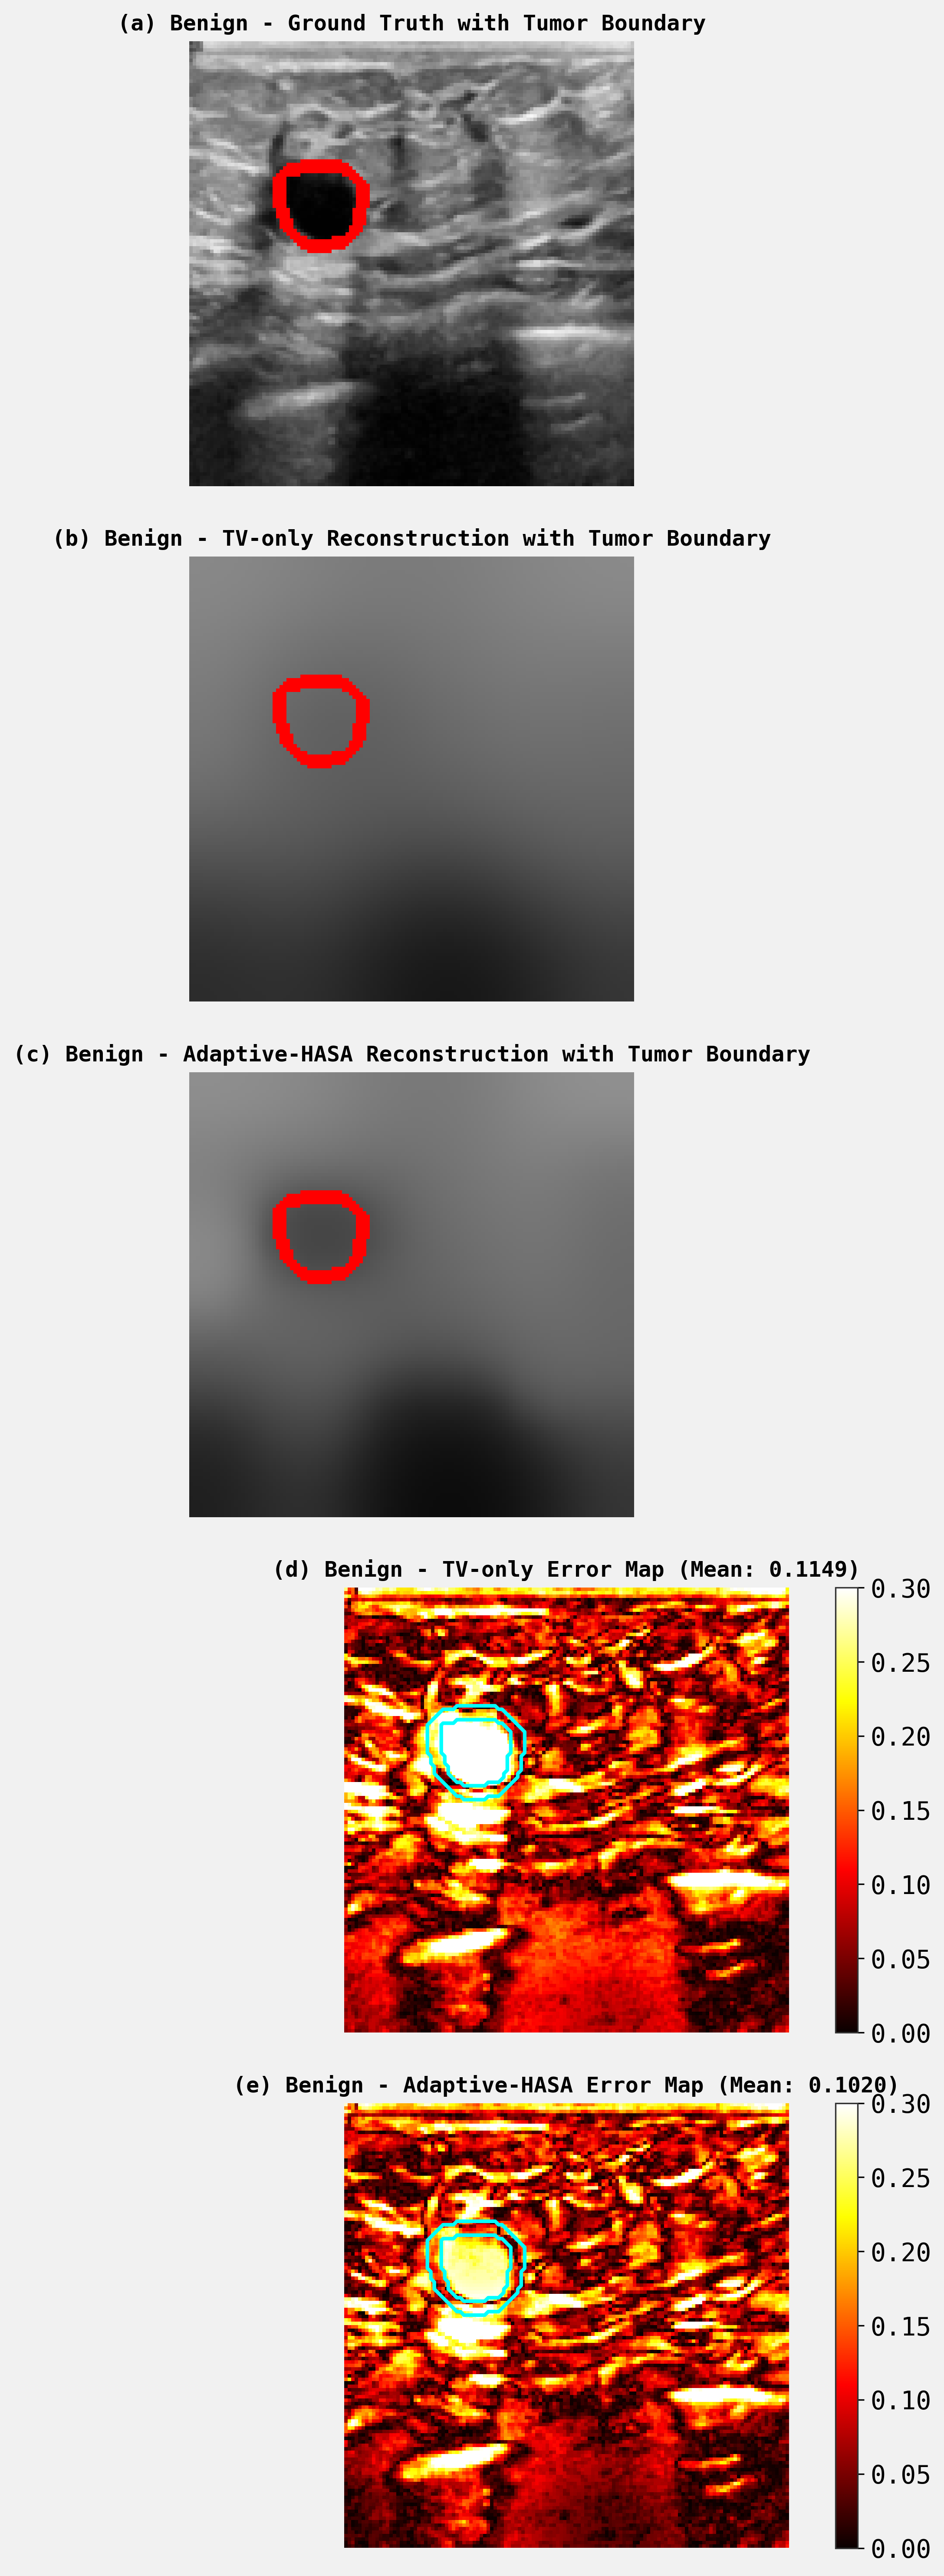

In [ ]:

# Step 10: Create comprehensive visualizations
# For each case (benign and malignant), create visualizations showing:
# a. Ground truth with tumor boundary
# b. TV-only reconstruction with tumor boundary
# c. Adaptive-HASA reconstruction with tumor boundary
# d. TV-only difference map
# e. Adaptive-HASA difference map

def create_image_with_boundary_overlay(image, boundary, boundary_color='red'):
    """Create RGB image with boundary overlay"""
    # Convert grayscale to RGB
    img_rgb = np.stack([image, image, image], axis=2)
    
    # Overlay boundary in specified color
    if boundary_color == 'red':
        img_rgb[boundary, 0] = 1.0  # Red channel
        img_rgb[boundary, 1] = 0.0  # Green channel
        img_rgb[boundary, 2] = 0.0  # Blue channel
    elif boundary_color == 'yellow':
        img_rgb[boundary, 0] = 1.0  # Red channel
        img_rgb[boundary, 1] = 1.0  # Green channel
        img_rgb[boundary, 2] = 0.0  # Blue channel
    
    return img_rgb

# Create visualizations for benign case
fig, axes = plt.subplots(5, 1, figsize=(8, 20))

# a. Ground truth with boundary
axes[0].imshow(create_image_with_boundary_overlay(benign_gt, benign_boundary))
axes[0].set_title('(a) Benign - Ground Truth with Tumor Boundary', fontsize=12, fontweight='bold')
axes[0].axis('off')

# b. TV-only reconstruction with boundary
axes[1].imshow(create_image_with_boundary_overlay(benign_tv_recon, benign_boundary))
axes[1].set_title('(b) Benign - TV-only Reconstruction with Tumor Boundary', fontsize=12, fontweight='bold')
axes[1].axis('off')

# c. Adaptive-HASA reconstruction with boundary
axes[2].imshow(create_image_with_boundary_overlay(benign_hasa_recon, benign_boundary))
axes[2].set_title('(c) Benign - Adaptive-HASA Reconstruction with Tumor Boundary', fontsize=12, fontweight='bold')
axes[2].axis('off')

# d. TV-only difference map
im1 = axes[3].imshow(benign_tv_error, cmap='hot', vmin=0, vmax=0.3)
axes[3].contour(benign_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[3].set_title(f'(d) Benign - TV-only Error Map (Mean: {benign_tv_error.mean():.4f})', fontsize=12, fontweight='bold')
axes[3].axis('off')
plt.colorbar(im1, ax=axes[3], fraction=0.046)

# e. Adaptive-HASA difference map
im2 = axes[4].imshow(benign_hasa_error, cmap='hot', vmin=0, vmax=0.3)
axes[4].contour(benign_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[4].set_title(f'(e) Benign - Adaptive-HASA Error Map (Mean: {benign_hasa_error.mean():.4f})', fontsize=12, fontweight='bold')
axes[4].axis('off')
plt.colorbar(im2, ax=axes[4], fraction=0.046)

plt.tight_layout()
plt.savefig('benign_reconstruction_analysis.png', dpi=150, bbox_inches='tight')
print("Benign case visualization saved to 'benign_reconstruction_analysis.png'")
plt.show()


Malignant case visualization saved to 'malignant_reconstruction_analysis.png'


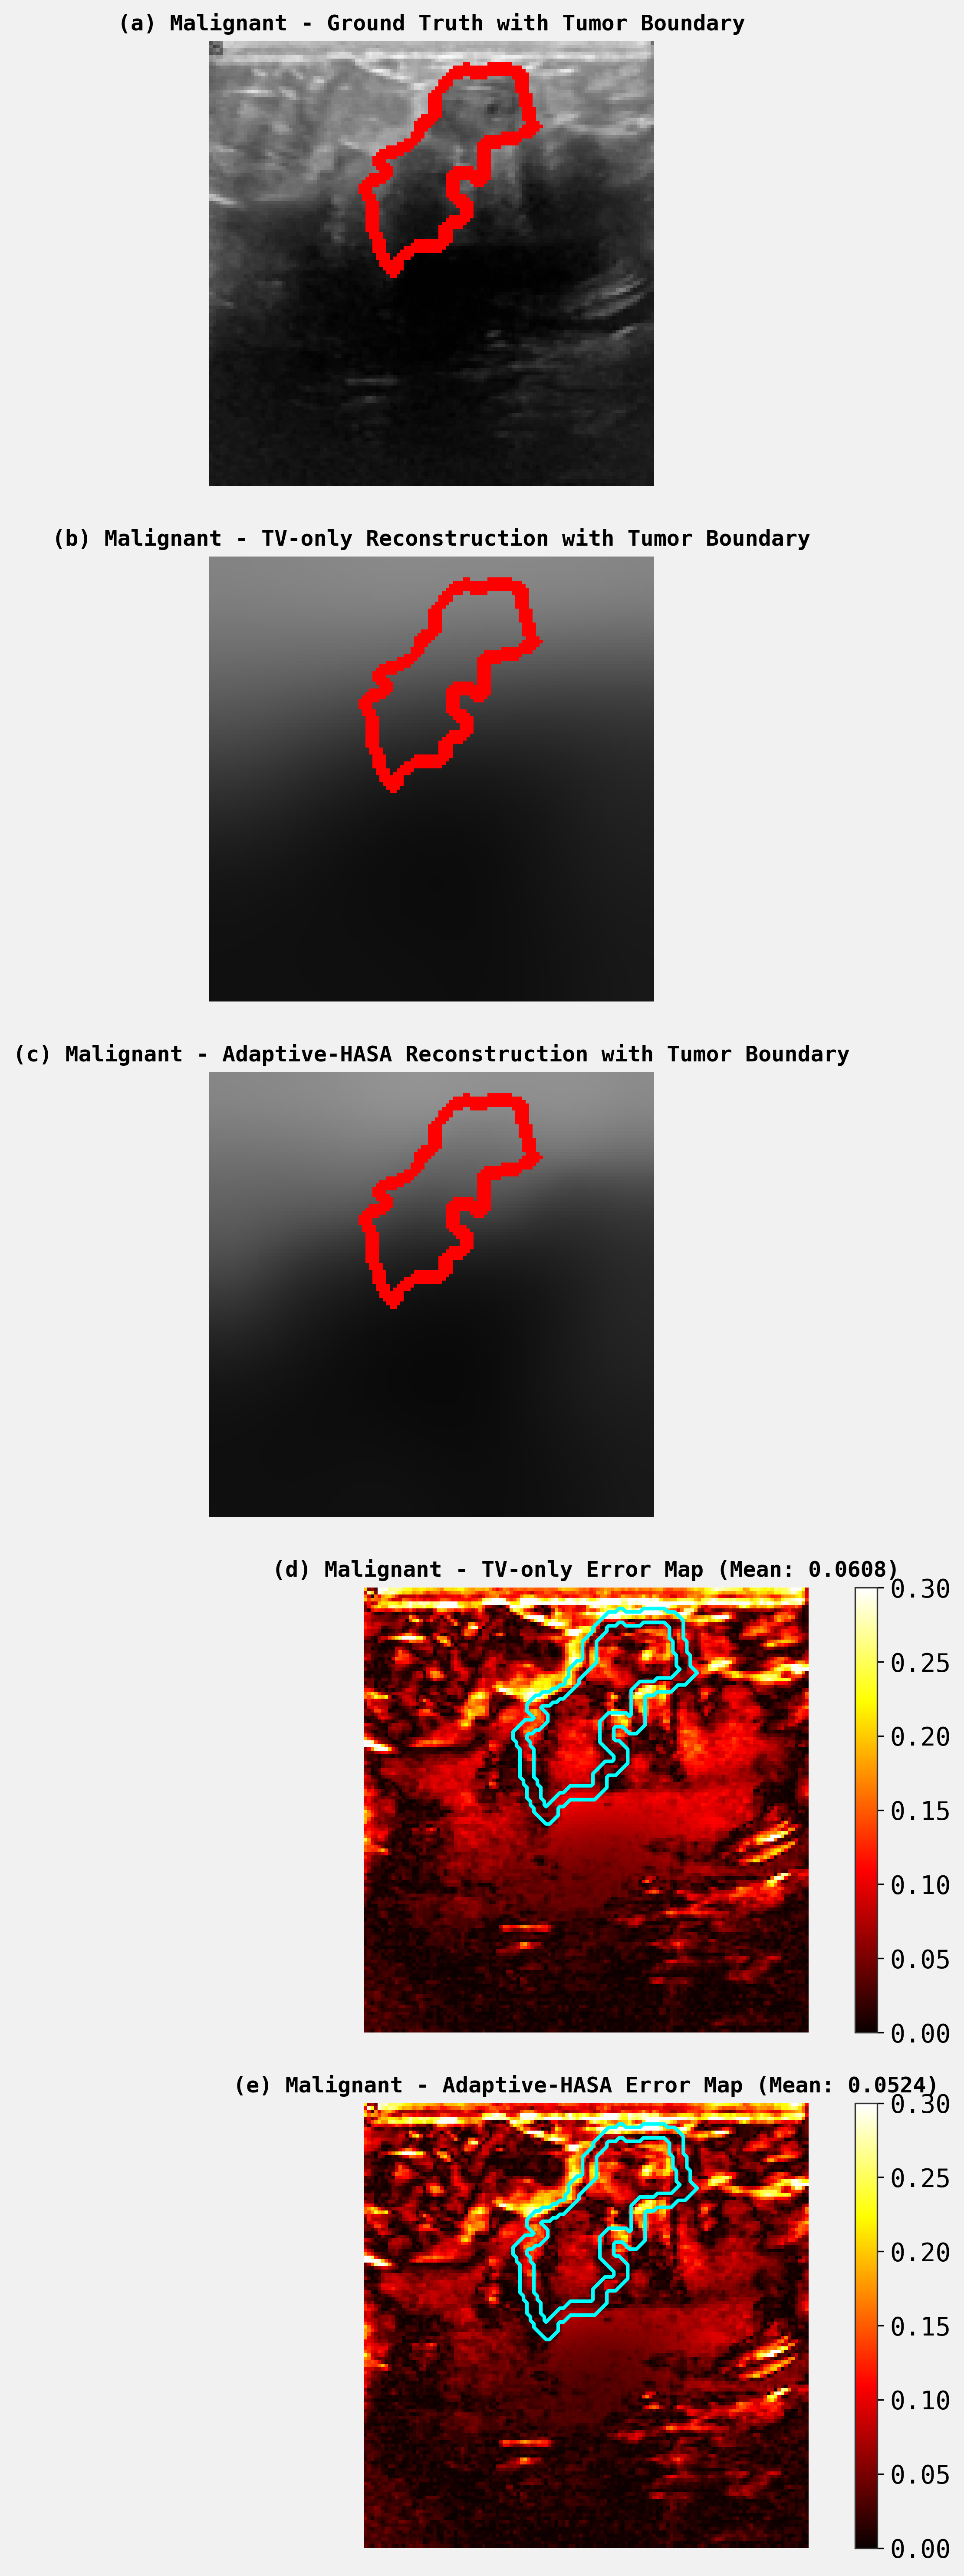

In [ ]:

# Step 11: Create comprehensive visualizations for malignant case
fig, axes = plt.subplots(5, 1, figsize=(8, 20))

# a. Ground truth with boundary
axes[0].imshow(create_image_with_boundary_overlay(malignant_gt, malignant_boundary))
axes[0].set_title('(a) Malignant - Ground Truth with Tumor Boundary', fontsize=12, fontweight='bold')
axes[0].axis('off')

# b. TV-only reconstruction with boundary
axes[1].imshow(create_image_with_boundary_overlay(malignant_tv_recon, malignant_boundary))
axes[1].set_title('(b) Malignant - TV-only Reconstruction with Tumor Boundary', fontsize=12, fontweight='bold')
axes[1].axis('off')

# c. Adaptive-HASA reconstruction with boundary
axes[2].imshow(create_image_with_boundary_overlay(malignant_hasa_recon, malignant_boundary))
axes[2].set_title('(c) Malignant - Adaptive-HASA Reconstruction with Tumor Boundary', fontsize=12, fontweight='bold')
axes[2].axis('off')

# d. TV-only difference map
im1 = axes[3].imshow(malignant_tv_error, cmap='hot', vmin=0, vmax=0.3)
axes[3].contour(malignant_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[3].set_title(f'(d) Malignant - TV-only Error Map (Mean: {malignant_tv_error.mean():.4f})', fontsize=12, fontweight='bold')
axes[3].axis('off')
plt.colorbar(im1, ax=axes[3], fraction=0.046)

# e. Adaptive-HASA difference map
im2 = axes[4].imshow(malignant_hasa_error, cmap='hot', vmin=0, vmax=0.3)
axes[4].contour(malignant_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[4].set_title(f'(e) Malignant - Adaptive-HASA Error Map (Mean: {malignant_hasa_error.mean():.4f})', fontsize=12, fontweight='bold')
axes[4].axis('off')
plt.colorbar(im2, ax=axes[4], fraction=0.046)

plt.tight_layout()
plt.savefig('malignant_reconstruction_analysis.png', dpi=150, bbox_inches='tight')
print("Malignant case visualization saved to 'malignant_reconstruction_analysis.png'")
plt.show()


Final comparison figure saved to 'final_reconstruction_comparison.png'


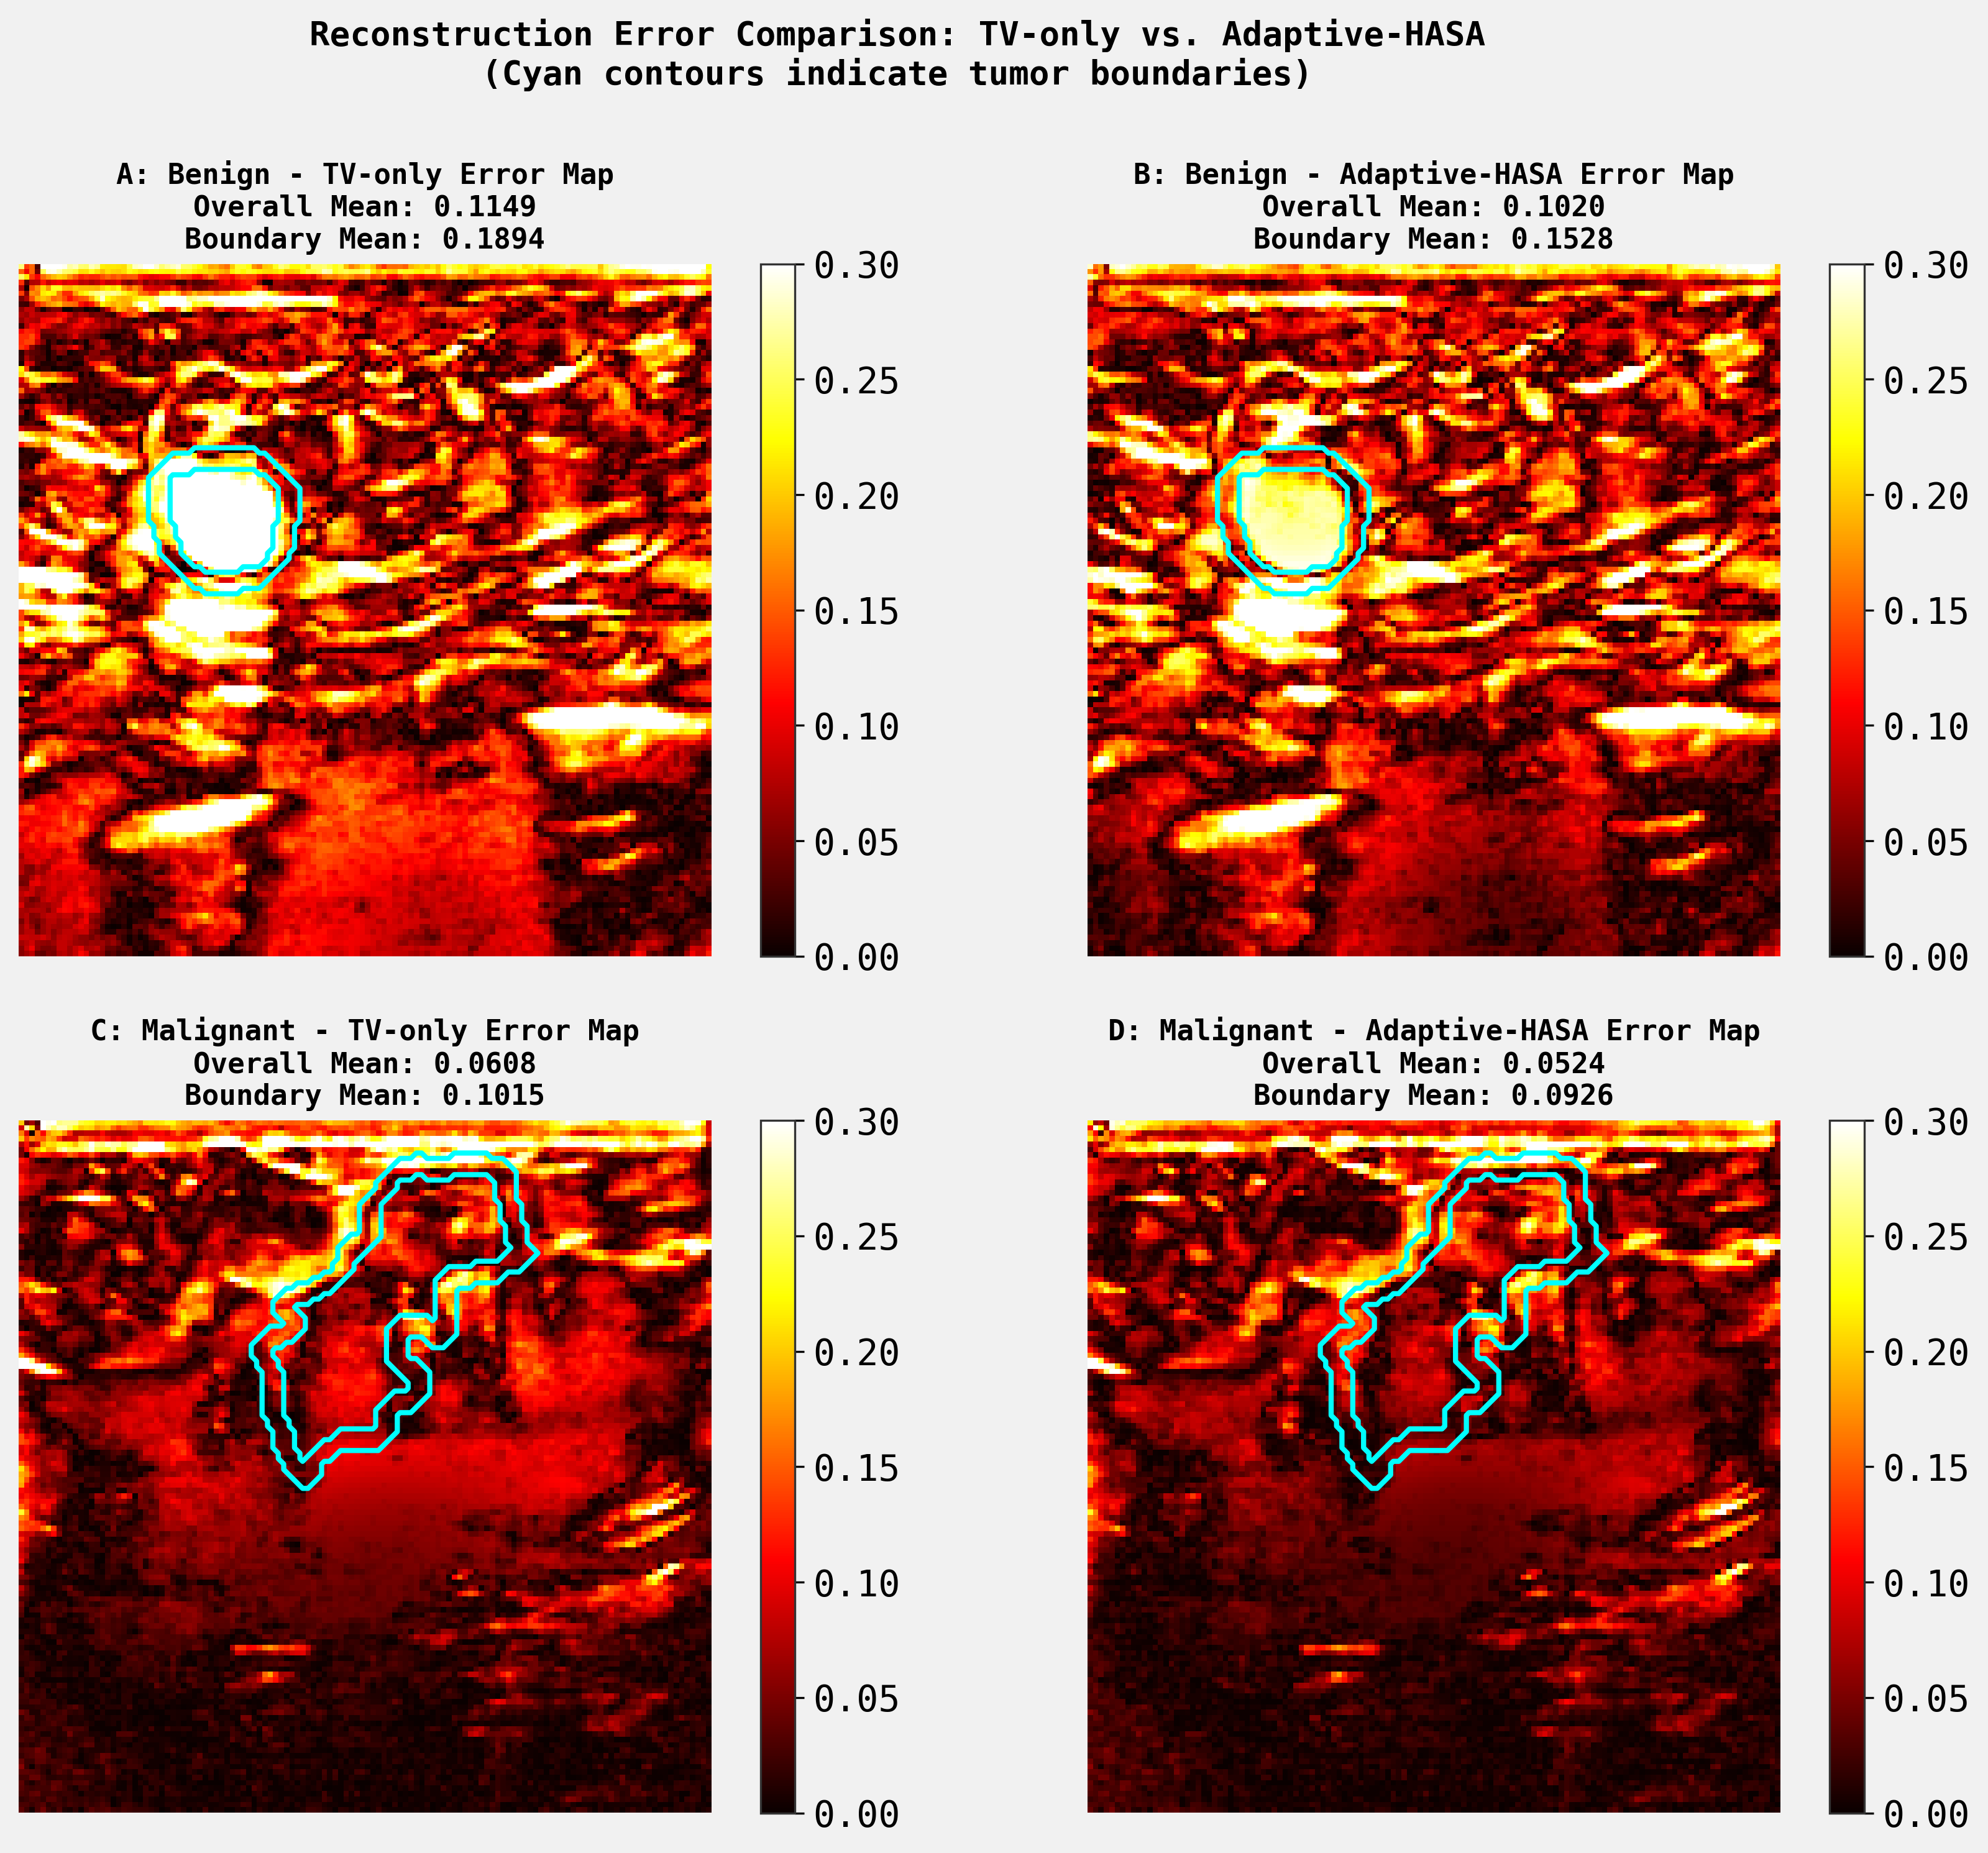

In [ ]:

# Step 12: Create final summary figure comparing methods side-by-side
# This will be a compact visualization showing key results for both cases

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top row: Benign case
# Left: TV-only error map with boundary
im1 = axes[0, 0].imshow(benign_tv_error, cmap='hot', vmin=0, vmax=0.3)
axes[0, 0].contour(benign_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[0, 0].set_title('A: Benign - TV-only Error Map\n' + 
                      f'Overall Mean: {benign_tv_error.mean():.4f}\n' +
                      f'Boundary Mean: {benign_tv_boundary_stats["boundary_mean"]:.4f}',
                      fontsize=11, fontweight='bold')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# Right: Adaptive-HASA error map with boundary
im2 = axes[0, 1].imshow(benign_hasa_error, cmap='hot', vmin=0, vmax=0.3)
axes[0, 1].contour(benign_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[0, 1].set_title('B: Benign - Adaptive-HASA Error Map\n' + 
                      f'Overall Mean: {benign_hasa_error.mean():.4f}\n' +
                      f'Boundary Mean: {benign_hasa_boundary_stats["boundary_mean"]:.4f}',
                      fontsize=11, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# Bottom row: Malignant case
# Left: TV-only error map with boundary
im3 = axes[1, 0].imshow(malignant_tv_error, cmap='hot', vmin=0, vmax=0.3)
axes[1, 0].contour(malignant_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[1, 0].set_title('C: Malignant - TV-only Error Map\n' + 
                      f'Overall Mean: {malignant_tv_error.mean():.4f}\n' +
                      f'Boundary Mean: {malignant_tv_boundary_stats["boundary_mean"]:.4f}',
                      fontsize=11, fontweight='bold')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

# Right: Adaptive-HASA error map with boundary
im4 = axes[1, 1].imshow(malignant_hasa_error, cmap='hot', vmin=0, vmax=0.3)
axes[1, 1].contour(malignant_boundary, colors='cyan', linewidths=2, levels=[0.5])
axes[1, 1].set_title('D: Malignant - Adaptive-HASA Error Map\n' + 
                      f'Overall Mean: {malignant_hasa_error.mean():.4f}\n' +
                      f'Boundary Mean: {malignant_hasa_boundary_stats["boundary_mean"]:.4f}',
                      fontsize=11, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

plt.suptitle('Reconstruction Error Comparison: TV-only vs. Adaptive-HASA\n(Cyan contours indicate tumor boundaries)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('final_reconstruction_comparison.png', dpi=150, bbox_inches='tight')
print("Final comparison figure saved to 'final_reconstruction_comparison.png'")
plt.show()


In [ ]:

# Step 13: Perform detailed statistical analysis of boundary vs non-boundary errors
# and create summary tables

print("="*80)
print("COMPREHENSIVE BOUNDARY ERROR ANALYSIS")
print("="*80)

# Create summary table for benign case
print("\n" + "="*80)
print("BENIGN CASE SUMMARY")
print("="*80)
print("\n{:<30s} {:>15s} {:>15s} {:>15s}".format("Metric", "TV-only", "Adaptive-HASA", "Improvement"))
print("-"*80)

# Overall errors
benign_overall_improvement = (benign_tv_error.mean() - benign_hasa_error.mean()) / benign_tv_error.mean() * 100
print("{:<30s} {:>15.6f} {:>15.6f} {:>14.1f}%".format(
    "Overall Mean Error", 
    benign_tv_error.mean(), 
    benign_hasa_error.mean(),
    benign_overall_improvement))

# Boundary errors
benign_boundary_improvement = (benign_tv_boundary_stats['boundary_mean'] - 
                                benign_hasa_boundary_stats['boundary_mean']) / benign_tv_boundary_stats['boundary_mean'] * 100
print("{:<30s} {:>15.6f} {:>15.6f} {:>14.1f}%".format(
    "Boundary Mean Error", 
    benign_tv_boundary_stats['boundary_mean'], 
    benign_hasa_boundary_stats['boundary_mean'],
    benign_boundary_improvement))

print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Boundary Std Error", 
    benign_tv_boundary_stats['boundary_std'], 
    benign_hasa_boundary_stats['boundary_std']))

print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Boundary Max Error", 
    benign_tv_boundary_stats['boundary_max'], 
    benign_hasa_boundary_stats['boundary_max']))

# Non-boundary errors
print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Non-Boundary Mean Error", 
    benign_tv_boundary_stats['non_boundary_mean'], 
    benign_hasa_boundary_stats['non_boundary_mean']))

# PSNR
benign_psnr_improvement = compute_psnr(benign_gt, benign_hasa_recon) - compute_psnr(benign_gt, benign_tv_recon)
print("{:<30s} {:>14.2f} dB {:>14.2f} dB {:>13.2f} dB".format(
    "PSNR", 
    compute_psnr(benign_gt, benign_tv_recon), 
    compute_psnr(benign_gt, benign_hasa_recon),
    benign_psnr_improvement))

# Create summary table for malignant case
print("\n" + "="*80)
print("MALIGNANT CASE SUMMARY")
print("="*80)
print("\n{:<30s} {:>15s} {:>15s} {:>15s}".format("Metric", "TV-only", "Adaptive-HASA", "Improvement"))
print("-"*80)

# Overall errors
malignant_overall_improvement = (malignant_tv_error.mean() - malignant_hasa_error.mean()) / malignant_tv_error.mean() * 100
print("{:<30s} {:>15.6f} {:>15.6f} {:>14.1f}%".format(
    "Overall Mean Error", 
    malignant_tv_error.mean(), 
    malignant_hasa_error.mean(),
    malignant_overall_improvement))

# Boundary errors
malignant_boundary_improvement = (malignant_tv_boundary_stats['boundary_mean'] - 
                                   malignant_hasa_boundary_stats['boundary_mean']) / malignant_tv_boundary_stats['boundary_mean'] * 100
print("{:<30s} {:>15.6f} {:>15.6f} {:>14.1f}%".format(
    "Boundary Mean Error", 
    malignant_tv_boundary_stats['boundary_mean'], 
    malignant_hasa_boundary_stats['boundary_mean'],
    malignant_boundary_improvement))

print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Boundary Std Error", 
    malignant_tv_boundary_stats['boundary_std'], 
    malignant_hasa_boundary_stats['boundary_std']))

print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Boundary Max Error", 
    malignant_tv_boundary_stats['boundary_max'], 
    malignant_hasa_boundary_stats['boundary_max']))

# Non-boundary errors
print("{:<30s} {:>15.6f} {:>15.6f}".format(
    "Non-Boundary Mean Error", 
    malignant_tv_boundary_stats['non_boundary_mean'], 
    malignant_hasa_boundary_stats['non_boundary_mean']))

# PSNR
malignant_psnr_improvement = compute_psnr(malignant_gt, malignant_hasa_recon) - compute_psnr(malignant_gt, malignant_tv_recon)
print("{:<30s} {:>14.2f} dB {:>14.2f} dB {:>13.2f} dB".format(
    "PSNR", 
    compute_psnr(malignant_gt, malignant_tv_recon), 
    compute_psnr(malignant_gt, malignant_hasa_recon),
    malignant_psnr_improvement))

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
print(f"\n1. Benign case boundary error reduction: {benign_boundary_improvement:.1f}%")
print(f"   - TV-only boundary mean error: {benign_tv_boundary_stats['boundary_mean']:.6f}")
print(f"   - Adaptive-HASA boundary mean error: {benign_hasa_boundary_stats['boundary_mean']:.6f}")

print(f"\n2. Malignant case boundary error reduction: {malignant_boundary_improvement:.1f}%")
print(f"   - TV-only boundary mean error: {malignant_tv_boundary_stats['boundary_mean']:.6f}")
print(f"   - Adaptive-HASA boundary mean error: {malignant_hasa_boundary_stats['boundary_mean']:.6f}")

print(f"\n3. Overall PSNR improvements:")
print(f"   - Benign: +{benign_psnr_improvement:.2f} dB")
print(f"   - Malignant: +{malignant_psnr_improvement:.2f} dB")

print("\n" + "="*80)


COMPREHENSIVE BOUNDARY ERROR ANALYSIS

BENIGN CASE SUMMARY

Metric                                 TV-only   Adaptive-HASA     Improvement
--------------------------------------------------------------------------------
Overall Mean Error                    0.114894        0.102027           11.2%
Boundary Mean Error                   0.189395        0.152770           19.3%
Boundary Std Error                    0.105449        0.089310
Boundary Max Error                    0.387367        0.437370
Non-Boundary Mean Error               0.113580        0.101132
PSNR                                    16.63 dB          17.50 dB          0.88 dB

MALIGNANT CASE SUMMARY

Metric                                 TV-only   Adaptive-HASA     Improvement
--------------------------------------------------------------------------------
Overall Mean Error                    0.060831        0.052418           13.8%
Boundary Mean Error                   0.101520        0.092641            8.7%
Bounda